In [1]:
import matplotlib.pyplot as plt
import rioxarray as rxr
import xarray as xr
import geopandas as gpd
import numpy as np
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap

plt.rcParams['font.family'] = 'Arial'
from shapely.geometry import Point
bound = gpd.GeoDataFrame({
    'x': [80, 150, 106.5, 123],
    'y': [15, 50, 2.8, 24.5]
})
# 添加矢量列
bound.geometry = bound.apply(lambda row: Point([row['x'], row['y']]), axis=1)
# 初始化CRS
bound.crs = 'EPSG:4326'
# 再投影
bound.to_crs('EPSG:2380', inplace=True)



e:\anaconda3\Lib\site-packages\geopandas\geodataframe.py:221: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  object.__setattr__(self, attr, val)


In [2]:
china_country = gpd.read_file(r"D:\6. Transfer\PhD_tht\GIS_layer\china-shapefiles\china_country_proj.shp")
china_country.geometry = china_country.geometry.to_crs('EPSG:2380')

Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


Text(580.4014069433665, 0.5, '')

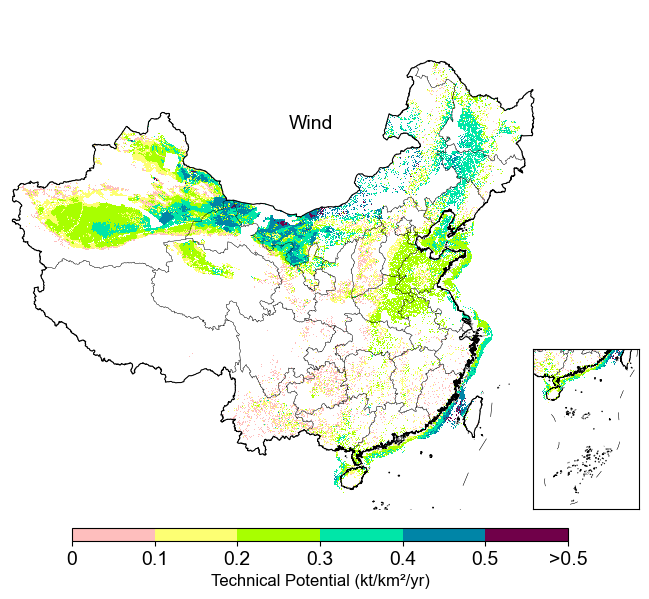

In [3]:
offwind = xr.open_dataarray("Figure2/offwind_h2_production_PEM.tif").squeeze() / 1e6
onwind = xr.open_dataarray("Figure2/onwind_h2_production_PEM.tif").squeeze() / 1e6
offwind = offwind.rio.reproject('EPSG:2380')
onwind = onwind.rio.reproject('EPSG:2380')
fig = plt.figure(figsize=(8, 8))
plt.rc('font', size=14)
plt.rc('axes', grid=False)
plt.rc('axes', facecolor='white')
ax = fig.add_subplot(1, 1, 1)
china = gpd.read_file(r"D:\00. Data set\GIS data\中华人民共和国.json")
china["geometry"] = china.geometry.to_crs('EPSG:2380')

arr1 = np.ravel(np.asarray(offwind.values))           # 定义离散色带
arr2 = np.ravel(np.asarray(onwind.values))
data_all = np.concatenate([arr1, arr2])
data_all = data_all[np.isfinite(data_all)]
vmin, vmax = np.nanmin(data_all), np.nanmax(data_all)
# 线性等距 6 段（7 个边界）
boundaries = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]  # 使用inf表示大于0.5的所有值
color_lst = ["#FEBEBD", "#FDFF73", "#A8FF00", "#00E6A8", "#0085A7", "#700049"]
cmap = ListedColormap(color_lst)
norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)


mappable = offwind.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)
onwind.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)

cbar = fig.colorbar(
    mappable, ax=ax,
    boundaries=boundaries,      # 告诉 colorbar 使用这些边界来离散显示
    ticks=[0., 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],           # 也可换成区间中点：(boundaries[:-1]+boundaries[1:])/2
    spacing="proportional",      # 段宽按数值范围比例显示
    orientation="horizontal",
    pad=0.03,
    aspect=40,
    shrink=0.8
)
cbar.set_ticklabels([
    '0', 
    '0.1', 
    '0.2', 
    '0.3', 
    '0.4', 
    '0.5','>0.5'
])
cbar.set_label("Technical Potential (kt/km²/yr)", fontsize=12)
china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax)
ax.set_axis_off()
ax.set_xlim(bound.geometry[0].x, bound.geometry[1].x)
ax.set_ylim(bound.geometry[0].y, bound.geometry[1].y)
plt.text(0.6e6, 5.5e6, "Wind", fontsize=14, ha='center', va='center')
plt.title("")

ax_child = fig.add_axes([0.72, 0.25, 0.25, 0.2])
ax_child = china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax_child)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax_child)
offwind.plot(ax=ax_child, cmap=cmap, norm=norm, add_colorbar=False)
onwind.plot(ax=ax_child, cmap=cmap, norm=norm, add_colorbar=False)
ax_child.set_xlim(bound.geometry[2].x, bound.geometry[3].x)
ax_child.set_ylim(bound.geometry[2].y, bound.geometry[3].y)
ax_child.set_xticks([])
ax_child.set_yticks([])
ax_child.set_title('')  # 去掉标题
ax_child.set_xlabel('') # 去掉x轴标签
ax_child.set_ylabel('') # 去掉y轴标签

Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


Text(580.4014069433665, 0.5, '')

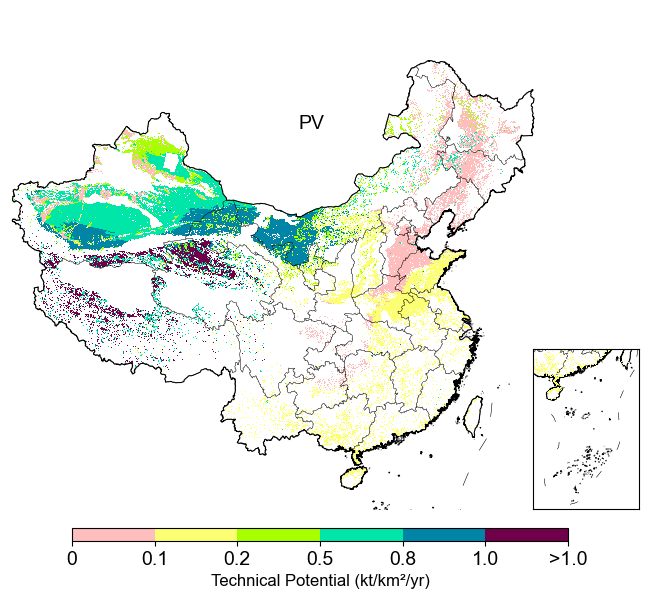

In [4]:
solar = xr.open_dataarray("Figure2/solar_h2_production_PEM.tif").squeeze() / 1e6
solar = solar.rio.reproject('EPSG:2380')
fig = plt.figure(figsize=(8, 8))
plt.rc('font', size=14)
plt.rc('axes', grid=False)
plt.rc('axes', facecolor='white')
ax = fig.add_subplot(1, 1, 1)
china = gpd.read_file(r"D:\00. Data set\GIS data\中华人民共和国.json")
china["geometry"] = china.geometry.to_crs('EPSG:2380')

boundaries = [0, 0.1, 0.2, 0.5, 0.8, 1, 1.5]  # 使用inf表示大于0.5的所有值
color_lst = ["#FEBEBD", "#FDFF73", "#A8FF00", "#00E6A8", "#0085A7", "#700049"]
cmap = ListedColormap(color_lst)
norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)

mappable = solar.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)

cbar = fig.colorbar(
    mappable, ax=ax,
    boundaries=boundaries,      # 告诉 colorbar 使用这些边界来离散显示
    ticks=[0, 0.1, 0.2, 0.5, 0.8, 1, 1.5],           # 也可换成区间中点：(boundaries[:-1]+boundaries[1:])/2
    spacing="uniform",      # 段宽按数值范围比例显示
    orientation="horizontal",
    pad=0.03,
    aspect=40,
    shrink=0.8
)
cbar.set_ticklabels([
    '0', 
    '0.1', 
    '0.2', 
    '0.5', 
    '0.8', 
    '1.0','>1.0'
])
cbar.set_label("Technical Potential (kt/km²/yr)", fontsize=12)
china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax)
ax.set_axis_off()
ax.set_xlim(bound.geometry[0].x, bound.geometry[1].x)
ax.set_ylim(bound.geometry[0].y, bound.geometry[1].y)
plt.text(0.6e6, 5.5e6, "PV", fontsize=14, ha='center', va='center')
plt.title("")

ax_child = fig.add_axes([0.72, 0.25, 0.25, 0.2])
ax_child = china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax_child)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax_child)
solar.plot(ax=ax_child, cmap=cmap, norm=norm, add_colorbar=False)
# onwind.plot(ax=ax_child, cmap=cmap, norm=norm, add_colorbar=False)
ax_child.set_xlim(bound.geometry[2].x, bound.geometry[3].x)
ax_child.set_ylim(bound.geometry[2].y, bound.geometry[3].y)
ax_child.set_xticks([])
ax_child.set_yticks([])
ax_child.set_title('')  # 去掉标题
ax_child.set_xlabel('') # 去掉x轴标签
ax_child.set_ylabel('') # 去掉y轴标签

In [3]:
ammonia = gpd.read_file("Figure6B/ammonia_all.shp")
ammonia.geometry = ammonia.geometry.to_crs('EPSG:2380')
cement = gpd.read_file("Figure6B/cement_all.shp")
cement.geometry = cement.geometry.to_crs('EPSG:2380')
glycol = gpd.read_file("Figure6B/glycol_all.shp")
glycol.geometry = glycol.geometry.to_crs('EPSG:2380')
syngas = gpd.read_file("Figure6B/syngas_all.shp")
syngas.geometry = syngas.geometry.to_crs('EPSG:2380')
liquid = gpd.read_file("Figure6B/liquid_all.shp")
liquid.geometry = liquid.geometry.to_crs('EPSG:2380')
olefin = gpd.read_file("Figure6B/olefin_all.shp")
olefin.geometry = olefin.geometry.to_crs('EPSG:2380')
steel = gpd.read_file("Figure6B/BOF_all.shp")
steel.geometry = steel.geometry.to_crs('EPSG:2380')
methanol = gpd.read_file("Figure6B/methanol_all.shp")
methanol.geometry = methanol.geometry.to_crs('EPSG:2380')
refinery = gpd.read_file("Figure6B/refinery_all.shp")
refinery.geometry = refinery.geometry.to_crs('EPSG:2380')

Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1
C:\Users\admin\AppData\Local\Temp\ipykernel_33832\2197641177.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


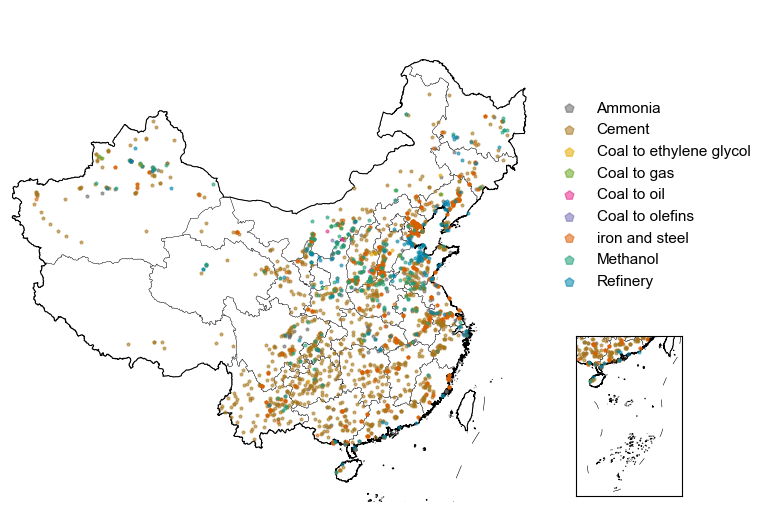

In [9]:
fig = plt.figure(figsize=(8, 8))
plt.rc('font', size=14)
plt.rc('axes', grid=False)
plt.rc('axes', facecolor='white')
ax = fig.add_subplot(1, 1, 1)
china = gpd.read_file(r"D:\00. Data set\GIS data\中华人民共和国.json")
china["geometry"] = china.geometry.to_crs('EPSG:2380')
china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax)
colors = plt.cm.Dark2_r(np.linspace(0, 1, 9))
alpha = 0.55
marker = 'p'
markersize = 5
ammonia.plot(ax=ax, color=colors[0], markersize=markersize, label='Ammonia', alpha=alpha, marker=marker)
cement.plot(ax=ax, color=colors[1], markersize=markersize, label='Cement', alpha=alpha, marker=marker)
glycol.plot(ax=ax, color=colors[2], markersize=markersize, label='Coal to ethylene glycol', alpha=alpha, marker=marker)
syngas.plot(ax=ax, color=colors[3], markersize=markersize, label='Coal to gas', alpha=alpha, marker=marker)
liquid.plot(ax=ax, color=colors[4], markersize=markersize, label='Coal to oil', alpha=alpha, marker=marker)
olefin.plot(ax=ax, color=colors[5], markersize=markersize, label='Coal to olefins', alpha=alpha, marker=marker)
steel.plot(ax=ax, color=colors[6], markersize=markersize, label='iron and steel', alpha=alpha, marker=marker)
methanol.plot(ax=ax, color=colors[7], markersize=markersize, label='Methanol', alpha=alpha, marker=marker)
refinery.plot(ax=ax, color="#0184A8", markersize=markersize, label='Refinery', alpha=alpha, marker=marker)
ax.set_axis_off()
ax.set_xlim(bound.geometry[0].x, bound.geometry[1].x)
ax.set_ylim(bound.geometry[0].y, bound.geometry[1].y)
plt.legend(loc='upper right', fontsize=11, markerscale=3, bbox_to_anchor=(1.25, 0.86),
           fancybox=False,  # 圆角边框
           shadow=False,  # 添加阴影
           borderpad=1,  # 边框与内容间距
           frameon=False,
           framealpha=0.9,
           edgecolor='gray',
           facecolor='ivory')  # 象牙色背景
ax_child = fig.add_axes([0.7, 0.2, 0.2, 0.2])
ax_child = china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax_child)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax_child)
ammonia.plot(ax=ax_child, color=colors[0], markersize=markersize, alpha=alpha, marker=marker)
cement.plot(ax=ax_child, color=colors[1], markersize=markersize, alpha=alpha, marker=marker)
glycol.plot(ax=ax_child, color=colors[2], markersize=markersize, alpha=alpha, marker=marker)
syngas.plot(ax=ax_child, color=colors[3], markersize=markersize, alpha=alpha, marker=marker)
liquid.plot(ax=ax_child, color=colors[4], markersize=markersize, alpha=alpha, marker=marker)
olefin.plot(ax=ax_child, color=colors[5], markersize=markersize, alpha=alpha, marker=marker)
steel.plot(ax=ax_child, color=colors[6], markersize=markersize, alpha=alpha, marker=marker)
methanol.plot(ax=ax_child, color=colors[7], markersize=markersize, alpha=alpha, marker=marker)
refinery.plot(ax=ax_child, color="#0184A8", markersize=markersize, alpha=alpha, marker=marker)

ax_child.set_xlim(bound.geometry[2].x, bound.geometry[3].x)
ax_child.set_ylim(bound.geometry[2].y, bound.geometry[3].y)
ax_child.set_xticks([])
ax_child.set_yticks([])
ax_child.set_title('')  # 去掉标题
ax_child.set_xlabel('') # 去掉x轴标签
ax_child.set_ylabel(''); # 去掉y轴标签
plt.tight_layout()
plt.savefig("point.svg")

In [7]:
low = gpd.read_file("Figure8A/low/h2_flow_2035.shp")
low.geometry = low.geometry.to_crs('EPSG:2380')
medium = gpd.read_file("Figure8A/medium/h2_flow_2035.shp")
medium.geometry = medium.geometry.to_crs('EPSG:2380')
high = gpd.read_file("Figure8A/high/h2_flow_2035.shp")
high.geometry = high.geometry.to_crs('EPSG:2380')

In [8]:
high

,Node1_FID,Node2_FID,length,h2_flow,geometry
0,52,159,142.813667,55.423552,"LINESTRING (1918.601 2856042.34, 55320.161 298..."
1,81,204,124.715577,4065.644369,"LINESTRING (606656.192 3976992.55, 703605.264 ..."
2,204,302,114.920855,3500.000000,"LINESTRING (703605.264 3898480.817, 810427.78 ..."
3,34,156,95.276858,4103.453856,"LINESTRING (1530439.671 4303117.512, 1499011.2..."
4,79,316,278.072105,2900.000000,"LINESTRING (23825.95 3434403.565, 274215.744 3..."
...,...,...,...,...,...
222,45,169,31.130045,206.770593,"LINESTRING (994289.857 2197361.913, 1023200.08..."
223,196,234,232.021998,2597.491000,"LINESTRING (954808.534 3735359.183, 1181386.54..."
224,272,318,139.990324,2200.000000,"LINESTRING (887230.796 4042540.829, 867265.462..."
225,272,281,79.467478,2066.382492,"LINESTRING (867265.462 3903733.614, 943177.722..."


Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


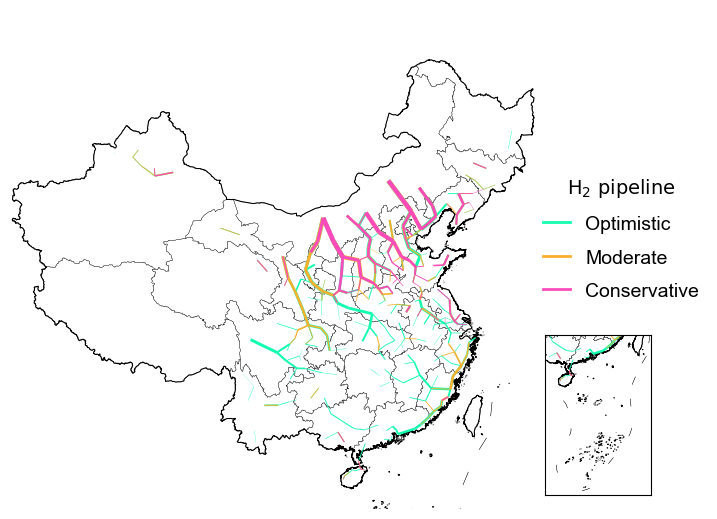

In [14]:

fig = plt.figure(figsize=(8, 8))
plt.rc('font', size=14)
plt.rc('axes', grid=False)
plt.rc('axes', facecolor='white')
ax = fig.add_subplot(1, 1, 1)
china = gpd.read_file(r"D:\00. Data set\GIS data\中华人民共和国.json")
china["geometry"] = china.geometry.to_crs('EPSG:2380')
china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax)
plt.rcParams["font.family"] = "Arial"
scale = 25
high.plot(ax=ax, color='#15FCAF', linewidth=np.sqrt(high["h2_flow"]) / scale, alpha=1, label='Optimistic')
medium.plot(ax=ax, color='#FAAF2D', linewidth=np.sqrt(medium["h2_flow"]) / scale, alpha=1, label='Moderate')
low.plot(ax=ax, color='#F94BBC', linewidth=np.sqrt(low["h2_flow"]) / scale, alpha=1, label='Conservative')
ax.set_axis_off()
ax.set_xlim(bound.geometry[0].x, bound.geometry[1].x)
ax.set_ylim(bound.geometry[0].y, bound.geometry[1].y)
legend_lw = 2.0  # 👈 图例里三条线统一的线宽（你可改 1.5 / 2 / 2.5）
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='#15FCAF', lw=legend_lw),
    Line2D([0], [0], color='#FAAF2D', lw=legend_lw),
    Line2D([0], [0], color='#F94BBC', lw=legend_lw),
]

legend_labels = ['Optimistic', 'Moderate', 'Conservative']
plt.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='upper right',
    fontsize=14,
    bbox_to_anchor=(1.14, 0.7),
    title=r"$\mathrm{H_2~pipeline}$",
    frameon=False,
    handlelength=1.4,
    labelspacing=0.8
)

ax_child = fig.add_axes([0.76, 0.2, 0.2, 0.2])
ax_child = china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax_child)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax_child)
high.plot(ax=ax_child, color='#15FCAF', linewidth=np.sqrt(high["h2_flow"]) / scale, alpha=1)
medium.plot(ax=ax_child, color='#FAAF2D', linewidth=np.sqrt(medium["h2_flow"]) / scale, alpha=1)
low.plot(ax=ax_child, color='#F94BBC', linewidth=np.sqrt(low["h2_flow"]) / scale, alpha=1)

ax_child.set_xlim(bound.geometry[2].x, bound.geometry[3].x)
ax_child.set_ylim(bound.geometry[2].y, bound.geometry[3].y)
ax_child.set_xticks([])
ax_child.set_yticks([])
ax_child.set_title('')  # 去掉标题
ax_child.set_xlabel('') # 去掉x轴标签
ax_child.set_ylabel(''); # 去掉y轴标签
plt.savefig("Figureabc.svg")

In [10]:
np.sqrt(500) / 25

0.894427190999916

In [28]:
from matplotlib.lines import Line2D

def add_h2flow_width_legend(ax, scale, color, title="h2_flow"):
    # 按 h2_flow 分档
    labels = [" < 0.5", "0.5 – 1.0", "1.0 – 2.0", " > 2.0"]
    # 每档取一个代表值（用于画示例线宽，避免用边界）
    reps = [500, 1000, 1500, 2500]  # 最后一档代表 >2，可改 2.5/4.0

    # 与你主图一致的线宽映射：lw = sqrt(flow)/scale
    lws = [np.sqrt(v) / scale for v in reps]

    handles = [
        Line2D([0], [0], color=color, lw=lw, solid_capstyle="round")
        for lw in lws
    ]

    leg = ax.legend(
        handles=handles,
        labels=labels,
        title=title,
        loc="upper right",
        fontsize=16,
        title_fontsize=16,
        bbox_to_anchor=(1.1, 0.83),
        frameon=False,
        handlelength=1.2,
        labelspacing=0.6
    )
    return leg


<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
C:\Users\admin\AppData\Local\Temp\ipykernel_34548\1467867331.py:50: SyntaxWarning: invalid escape sequence '\m'
  add_h2flow_width_legend(ax, scale=scale, color="#000000", title="$\mathrm{H_2~flow}$ \n $\mathrm{(Mt/yr)}$")
Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


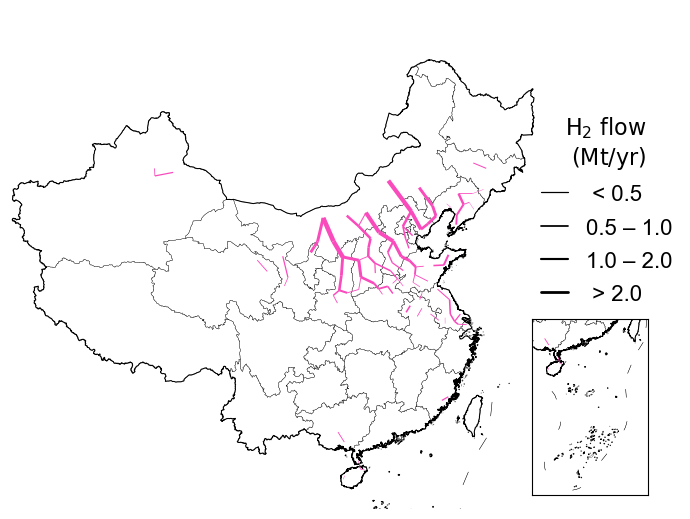

Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


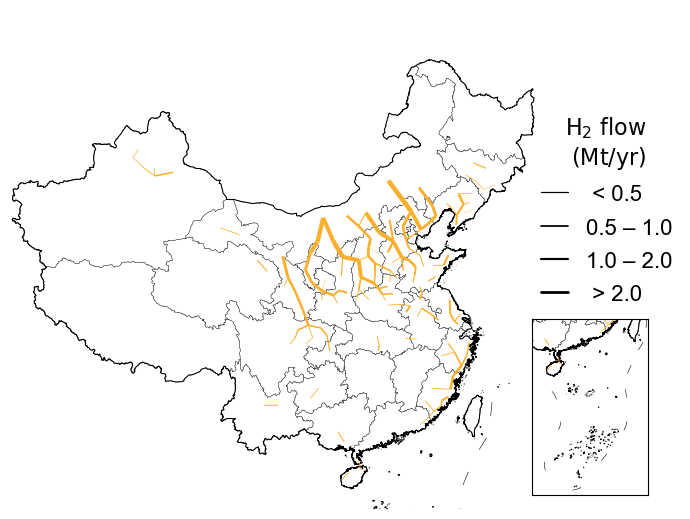

Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


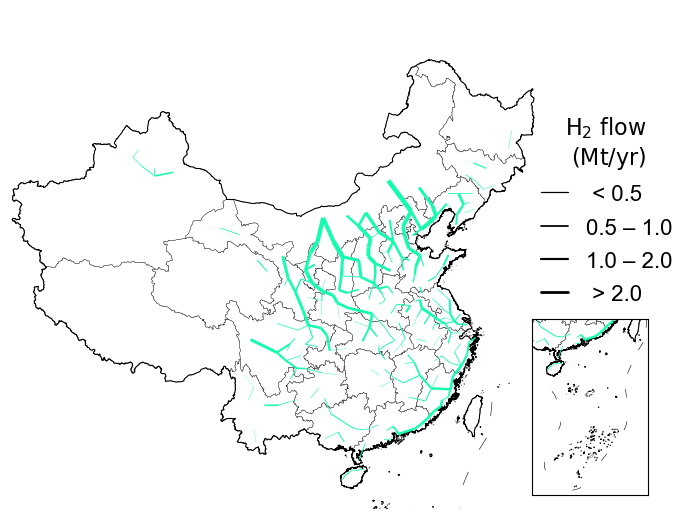

In [31]:
import matplotlib.pyplot as plt
import geopandas as gpd
#改变字体为ariel
plt.rcParams["font.family"] = "Arial"

# 创建三个独立的图形，每个对应一个情景
scenarios = [
    {'name': 'Low Scenario', 'data': low, 'color': "#F94BBC"},
    {'name': 'Medium Scenario', 'data': medium, 'color': "#FAAF2D"},
    {'name': 'High Scenario', 'data': high, 'color': "#15FCAF"}
]

for scenario in scenarios:
    fig = plt.figure(figsize=(8, 8))
    plt.rc('font', size=14)
    plt.rc('axes', grid=False)
    plt.rc('axes', facecolor='white')
    ax = fig.add_subplot(1, 1, 1)
    
    # 加载中国边界数据
    china = gpd.read_file(r"D:\00. Data set\GIS data\中华人民共和国.json")
    china["geometry"] = china.geometry.to_crs('EPSG:2380')
    china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax)
    china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax)
    # 绘制当前情景的管线
    scale = 25
    scenario['data'].plot(
        ax=ax, 
        color=scenario['color'], 
        linewidth=np.sqrt(scenario['data']["h2_flow"]) / scale, 
        alpha=1, 
        # label=scenario['name']
    )
    
    ax.set_axis_off()
    ax.set_xlim(bound.geometry[0].x, bound.geometry[1].x)
    ax.set_ylim(bound.geometry[0].y, bound.geometry[1].y)
    
    
    # 添加小地图
    ax_child = fig.add_axes([0.74, 0.2, 0.22, 0.22])
    ax_child = china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax_child)
    china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax_child)
    scenario['data'].plot(
        ax=ax_child, 
        color=scenario['color'], 
        linewidth=np.sqrt(scenario['data']["h2_flow"]) / scale, 
        alpha=1
    )
    add_h2flow_width_legend(ax, scale=scale, color="#000000", title="$\mathrm{H_2~flow}$ \n $\mathrm{(Mt/yr)}$")
    ax_child.set_xlim(bound.geometry[2].x, bound.geometry[3].x)
    ax_child.set_ylim(bound.geometry[2].y, bound.geometry[3].y)
    ax_child.set_xticks([])
    ax_child.set_yticks([])
    ax_child.set_title('')
    ax_child.set_xlabel('')
    ax_child.set_ylabel('')
    
    # 保存图形
    plt.savefig(f"{scenario['name'].replace(' ', '_').lower()}.svg", dpi=300, bbox_inches='tight')
    plt.show()



Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


NameError: name 'add_flow_width_legend' is not defined

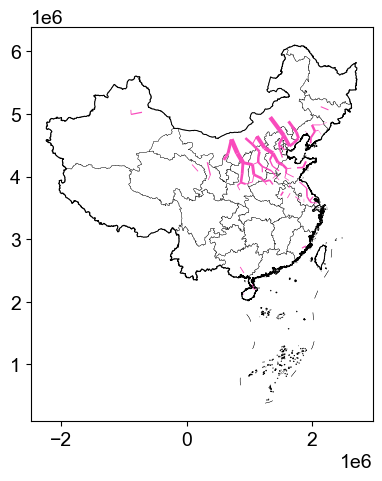

In [13]:
# 如果需要同时显示三个情景的对比图（可选）
fig_combined = plt.figure(figsize=(15, 8))
plt.rc('font', size=14)
plt.rc('axes', grid=False)
plt.rc('axes', facecolor='white')

# 创建三个子图
for i, scenario in enumerate(scenarios, 1):
    ax = fig_combined.add_subplot(1, 3, i)
    
    # 1. 主图绘制
    china = gpd.read_file(r"D:\00. Data set\GIS data\中华人民共和国.json")
    china["geometry"] = china.geometry.to_crs('EPSG:2380')
    china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax)
    china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax)
    scale = 25
    scenario['data'].plot(
        ax=ax, 
        color=scenario['color'], 
        linewidth=np.sqrt(scenario['data']["h2_flow"]) / scale, 
        alpha=1
    )
    add_flow_width_legend(ax, scale=scale, color="#6B6969", title="h2_flow")
    ax.set_axis_off()
    ax.set_xlim(bound.geometry[0].x, bound.geometry[1].x)
    ax.set_ylim(bound.geometry[0].y, bound.geometry[1].y)
    # ax.set_title(scenario['name'], fontsize=14)
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    # 2. 嵌入九段线子图 (使用 inset_axes)
    # width/height 可以是百分比，loc=4 代表右下角
    ax_child = inset_axes(ax, 
        width="30%", 
        height="30%", 
        loc='lower left',                 # 1. 设定子图的哪个角作为锚点 (这里选左下角方便定位)
        bbox_to_anchor=(0.75, 0.05, 1, 1),  # 2. 设定锚点在主图中的坐标 (x, y, 宽, 高)
        bbox_transform=ax.transAxes,      # 3. 声明坐标系为轴坐标 (0-1之间)
        borderpad=0                       # 4. 去除默认边距，完全由坐标控制
    )
    china.plot(facecolor="none", edgecolor="black", linewidth=0.2, ax=ax_child)
    china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax_child)
    scenario['data'].plot(
        ax=ax_child, 
        color=scenario['color'], 
        linewidth=np.sqrt(scenario['data']["h2_flow"]) / scale, 
        alpha=1
    )
    
    ax_child.set_xlim(bound.geometry[2].x, bound.geometry[3].x)
    ax_child.set_ylim(bound.geometry[2].y, bound.geometry[3].y)
    ax_child.set_xticks([])
    ax_child.set_yticks([])

plt.tight_layout()
plt.show()

Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


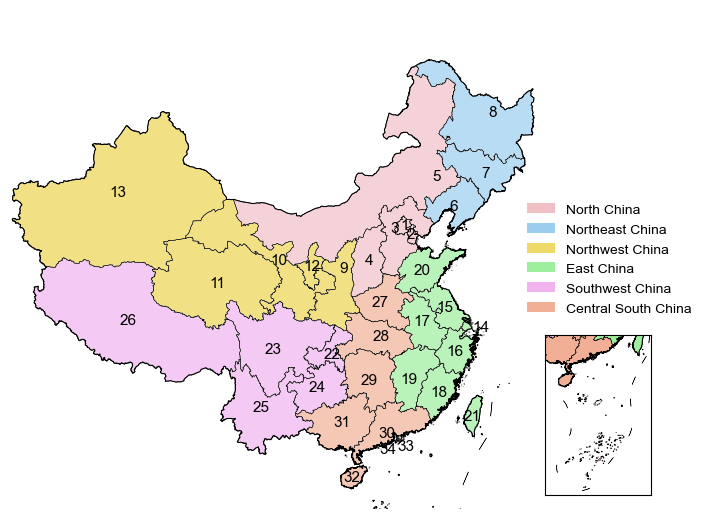

省份编号对照表：
【华北地区】
  1.北京市 2.天津市 3.河北省 4.山西省 5.内蒙古自治区
【东北地区】
  6.辽宁省 7.吉林省 8.黑龙江省
【西北地区】
  9.陕西省 10.甘肃省 11.青海省 12.宁夏回族自治区 13.新疆维吾尔自治区
【华东地区】
  14.上海市 15.江苏省 16.浙江省 17.安徽省 18.福建省 19.江西省 20.山东省 21.台湾省
【西南地区】
  22.重庆市 23.四川省 24.贵州省 25.云南省 26.西藏自治区
【中南地区】
  27.河南省 28.湖北省 29.湖南省 30.广东省 31.广西壮族自治区 32.海南省 33.香港特别行政区 34.澳门特别行政区


In [3]:
# 定义六大地理分区及其包含的省份（按指定顺序）
regions_def = {
    "华北地区": ["北京市", "天津市", "河北省", "山西省", "内蒙古自治区"],
    "东北地区": ["辽宁省", "吉林省", "黑龙江省"],
    "西北地区": ["陕西省", "甘肃省", "青海省", "宁夏回族自治区", "新疆维吾尔自治区"],
    "华东地区": ["上海市", "江苏省", "浙江省", "安徽省", "福建省", "江西省", "山东省", "台湾省"],
    "西南地区": ["重庆市", "四川省", "贵州省", "云南省", "西藏自治区"],
    "中南地区": ["河南省", "湖北省", "湖南省", "广东省", "广西壮族自治区", "海南省", "香港特别行政区", "澳门特别行政区"]
}

# 定义分区颜色
region_colors = {
    "华北地区": "#F1C0C7", # 浅粉红
    "东北地区": "#9BCEEE", # 浅天蓝
    "西北地区": "#ECD550DC", # 金色
    "华东地区": "#9DEF9D", # 浅绿
    "西南地区": "#F0B3F0", # 梅红
    "中南地区": "#F1B096"  # 浅鲑鱼色
}

# 重新加载数据以确保干净的环境
china = gpd.read_file(r"D:\00. Data set\GIS data\中华人民共和国.json")
china["geometry"] = china.geometry.to_crs('EPSG:2380')

# 辅助函数：根据省份名称匹配分区和编号
def get_region_info(prov_name):
    # 过滤无效名称
    if not isinstance(prov_name, str) or len(prov_name) < 2:
        return "其他", 99
        
    idx_counter = 1
    for region, provinces in regions_def.items():
        for p in provinces:
            # 简单的模糊匹配，处理“省”、“市”后缀差异，取前两个字匹配通常足够
            if p.startswith(prov_name[:2]): 
                return region, idx_counter
            idx_counter += 1
    return "其他", 99

# 应用匹配
china['region'] = china['name'].apply(lambda x: get_region_info(x)[0])
china['number'] = china['name'].apply(lambda x: get_region_info(x)[1])

# 绘图
fig, ax = plt.subplots(figsize=(8, 8))
plt.rc('font', size=15)

# 绘制每个分区
for region, color in region_colors.items():
    subset = china[china['region'] == region]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5, alpha=0.7)

# 绘制国界线
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax)
china.plot(facecolor="none", edgecolor="black", linewidth=0.35, ax=ax)
# 手动调整部分省份的标签位置 (x_offset, y_offset)
# 单位是米 (EPSG:2380 投影坐标系)
label_offsets = {
    "河北省": (-0.3e5, 0.8e5),      # 避开北京天津
    "内蒙古自治区": (2e5, -1e5),    # 往右下移一点
    "陕西省": (0, 1.5e5),           # 往上移，避开中部拥挤
    "甘肃省": (0, 0),            # 往左移
    # "天津市": (0.8e5, -0.5e5),      # 往右下移
    # "北京市": (-0.5e5, 0.5e5),      # 往左上移
    "上海市": (1.3e5, 0),           # 往右移出陆地
    "香港特别行政区": (0.6e5, -0.8e5), # 往右下
    "澳门特别行政区": (-0.6e5, -0.8e5),# 往左下
    "宁夏回族自治区": (0.2e5, 0),
    "重庆市": (0.2e5, -0.5e5)
}

# 添加省份数字标签
for idx, row in china.iterrows():
    if row['number'] != 99:
        # 默认使用 representative_point
        pt = row['geometry'].representative_point()
        x, y = pt.x, pt.y
        
        # 应用手动调整
        if row['name'] in label_offsets:
            dx, dy = label_offsets[row['name']]
            x += dx
            y += dy
            
        plt.text(x, y, str(row['number']), fontsize=11, ha='center', va='center', color='black', fontweight='normal')

# 创建自定义图例
from matplotlib.patches import Patch
# 英文映射
region_en_map = {
    "华北地区": "North China",
    "东北地区": "Northeast China",
    "西北地区": "Northwest China",
    "华东地区": "East China",
    "西南地区": "Southwest China",
    "中南地区": "Central South China"
}
legend_elements = [Patch(facecolor=region_colors[r], edgecolor='None', label=region_en_map[r]) for r in regions_def.keys()]
# 将图例移动到右侧中间，去掉边框
ax.legend(handles=legend_elements, loc='center right', title="", fontsize=10, frameon=False, bbox_to_anchor=(1.12, 0.5))

# 设置坐标轴
ax.set_axis_off()
# 使用之前定义的 bound 范围
ax.set_xlim(bound.geometry[0].x, bound.geometry[1].x)
ax.set_ylim(bound.geometry[0].y, bound.geometry[1].y)

# 添加小地图（南海诸岛）
ax_child = fig.add_axes([0.76, 0.2, 0.2, 0.2])
# 小地图也上色 (与主图逻辑一致)
for region, color in region_colors.items():
    subset = china[china['region'] == region]
    if not subset.empty:
        subset.plot(ax=ax_child, color=color, edgecolor='white', linewidth=0.2)

# 绘制国界线 (与主图逻辑一致)
china_country.plot(facecolor="none", edgecolor="black", linewidth=0.75, ax=ax_child)
china.plot(facecolor="none", edgecolor="black", linewidth=0.35, ax=ax_child)
ax_child.set_xlim(bound.geometry[2].x, bound.geometry[3].x)
ax_child.set_ylim(bound.geometry[2].y, bound.geometry[3].y)
ax_child.set_xticks([])
ax_child.set_yticks([])

# plt.title("", fontsize=16)
plt.show()

# 打印省份编号对照表
print("省份编号对照表：")
sorted_china = china[china['number'] != 99].sort_values('number')
for region in regions_def.keys():
    print(f"【{region}】")
    region_provs = sorted_china[sorted_china['region'] == region]
    prov_strs = [f"{row['number']}.{row['name']}" for _, row in region_provs.iterrows()]
    print("  " + " ".join(prov_strs))